# RTU example usage

This notebook will show a worked example using the RTU-grid subclass provided in this repo.  We will use the model and true mass parameters and the arc mask for Mock 1 from Enzi et al. 2026.

We will be making use of [jax_lensing_profiles](https://github.com/Herculens/Jax-Lensing-Profiles) in this example.

## Imports
The various imports we will be using in this notebook.

In [ ]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.interpolate import interpn

from herculens import PSF, Noise, PixelGrid
from herculens import MassModel, LensImage
from Herculens_overrides import (
    LightModelRTU,
    PixelatedLightRTU,
    LensImageRTUGrid,
    SimpleFFTConvolve
)
import jax_lensing_profiles

from astropy.io import fits

For plotting later make a nice colormap

In [2]:
def half_colormap(cmap_name='viridis', half='upper', n=256):
    cmap = plt.get_cmap(cmap_name)
    if half == 'lower':
        c = cmap(np.linspace(0.0, 0.5, n))
    elif half == 'upper':
        c = cmap(np.linspace(0.5, 1.0, n))
    else:
        raise ValueError("half must be 'lower' or 'upper'")
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f"{cmap_name}_{half}_half", c
    )
    return new_cmap


new_cmap =half_colormap("PuOr_r")

## Read in the mask

The arc mask for Mock 1 is provided in the included `.fits` file.  The full mock data is also included in this file along with the best fit from SVI as presented in the paper.  For this example we just need the mask.

In [ ]:
mask = jnp.array(fits.getdata('mock_paper_data.fits', extname="mask").astype(bool))

## Set up a Herculens pixel grid and noise

Make a standard Herculens `PixelGrid` and `Noise` classes for our observations that is 200x200 pixels with a pixel size of 0.031 arcseconds and an exposure time of 2000 seconds.

In [4]:
npix = 200  # number of pixel on a side
pix_scl = 0.031  # pixel size in arcsec

half_size = npix * pix_scl / 2.
ra_at_xy_0 = dec_at_xy_0 = -half_size + pix_scl / 2.

transform_pix2angle = pix_scl * np.eye(2)
pixel_grid = PixelGrid(
    nx=npix, ny=npix, 
    ra_at_xy_0=ra_at_xy_0, dec_at_xy_0=dec_at_xy_0,
    transform_pix2angle=transform_pix2angle
)

xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent

# bounds used for plotting
half_pixel_scale = 0.5 * pix_scl
bounds = [
    x_axis[0] - half_pixel_scale,
    x_axis[-1] + half_pixel_scale,
    y_axis[0] - half_pixel_scale, 
    y_axis[-1] + half_pixel_scale
]

print(f"image size : ({npix}, {npix}) pixels")
print(f"pixel size : {pix_scl} arcsec")
print(f"x range    : {xgrid[0, 0], xgrid[0, -1]} arcsec")
print(f"y range    : {ygrid[0, 0], ygrid[-1, 0]} arcsec")

noise = Noise(npix, npix, exposure_time=2000.0)

image size : (200, 200) pixels
pixel size : 0.031 arcsec
x range    : (-3.0845000000000002, 3.0844999999999994) arcsec
y range    : (-3.0845000000000002, 3.0844999999999994) arcsec


## Make the PSF kernel

For the RTU-grid subclass the PSF must be provided as a pixelated kernel.  This code converts the gaussian PSF of the mock into the correctly sized pixel grid.

In [5]:
# FWHM to sigma
sigma2 = 1 / (2 * jnp.log(2))

# a 15x15 kernel
psf_coords = jnp.linspace(-7, 7, 15)
psf_xx, psf_yy = jnp.meshgrid(psf_coords, psf_coords)
psf_rr2 = psf_xx**2 + psf_yy**2

psf_kernel = jnp.exp(-0.5 * psf_rr2/sigma2)
psf_kernel /= psf_kernel.sum()

## RTU-grid model

Our models looks very similar to a base gird Herculens model.  The differences are:
- Use the `PixelatedLightRTU` and `LightModelRTU` subclasses instead of `PixelatedLight` and `LightModel`
- `PixelatedLightRTU` needs the `rtu_grid=False` as this represents the uniform grid in the transformed space.
    - The new class will correctly set the range and position of this grid internally
    - `rtu_grid_type` and `rtu_poly_order` can also be set on `PixelatedLightRTU`
    - The size of this pixel grid is set the normal way (via `kwargs_pixelated` of `LightModelRTU`)
- The PSF must use the `SimpleFFTConvolve` class rather than the normal PSF class
- A "psf_holder" class is passed in the normal PSF spot (this will never be used)
- the `LensImageRTUGrid` subclass is used
    - `rtu_mesh_weights` can be used to pass in rtu importance weights for each pixel when defining the transformation (similar to an arc mask these are assumed to be fixed values that will not change during inference)

In [6]:
lens_mass_input = MassModel(["EPL", "NFW", "SHEAR"])

psf_holder = PSF(psf_type='NONE')
pixel_grid_shape = 64

source_input_rtu = LightModelRTU([
    PixelatedLightRTU(
        interpolation_type='fast_bilinear',
        derivative_type='autodiff',
        rtu_grid=True,
        allow_extrapolation=False
    )
], kwargs_pixelated={'num_pixels': pixel_grid_shape})

psf_rtu = SimpleFFTConvolve(psf_kernel, (npix, npix))

kwargs_numerics = {'supersampling_factor': 4}

lens_image_rtu = LensImageRTUGrid(
    pixel_grid, psf_holder, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input_rtu,
    kwargs_numerics=kwargs_numerics,
    source_arc_mask=mask
)

## Some mass parameters

These are the true mass parameters for Mock 1.  We will be using these as we know the mask we read in will be focused with these parameters.

In [7]:
kwargs_lens = [
    # EPL
    {'theta_E': 1.5, 'gamma': 2.1, 'e1': 0.1, 'e2': -0.05, 'center_x': 0.01, 'center_y': 0.0},
    # NFW
    {'kappa_s': 10**0.3, 'R_s': 10**-1.42, 'center_x': -1.6, 'center_y': 0.0},
    # SHEAR
    {'gamma1': -0.03, 'gamma2': 0.02, 'ra_0': 0.0, 'dec_0': 0.0}
]

## Make a gaussian source

For simplicity we will make a gaussian source in the uniformed transformed space of the RTU-grid.  It is the source in this transformed space that is input into `model` function.

In [8]:
source_coords = jnp.linspace(-1, 1, pixel_grid_shape) * pix_scl
source_xx, source_yy = jnp.meshgrid(source_coords, source_coords)
source_rr2 = source_xx**2 + source_yy**2

source = 5 * jnp.exp(-0.5 * source_rr2/0.005**2)

kwargs_source_uniform = [{'pixels': source}]

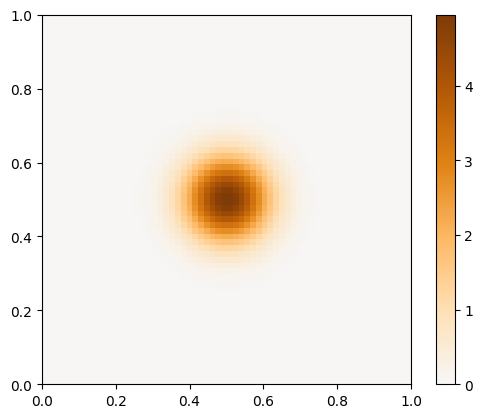

In [9]:
plt.imshow(source, extent=[0, 1, 0, 1], cmap=new_cmap, vmin=0)
plt.colorbar();

## Call the model

For plotting the source in observed coordinates we will need `return_source_pixels_coords=True`.

In [10]:
rtu_model, (source_centers, source_edges) = lens_image_rtu.model(
    kwargs_lens=kwargs_lens,
    kwargs_source=kwargs_source_uniform,
    PSF_class=psf_rtu,
    return_source_pixels_coords=True
)

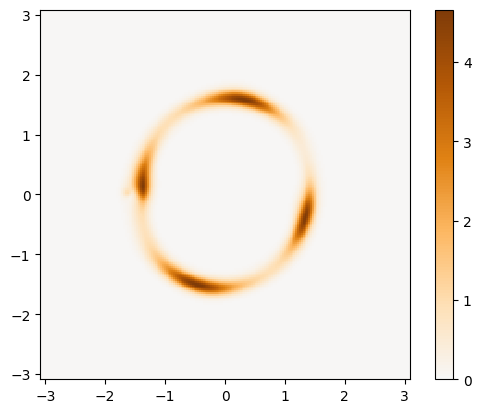

In [11]:
plt.imshow(rtu_model, extent=pixel_grid.extent, cmap=new_cmap, vmin=0)
plt.colorbar();

## Visualize the source

The source pixels that were passed into the model were the ones in the uniform transformed space.  If we want to see the source in observed coordinates we can use `pcolormesh` to plot the non-uniform pixel grid using the source pixel edges returned by the model.

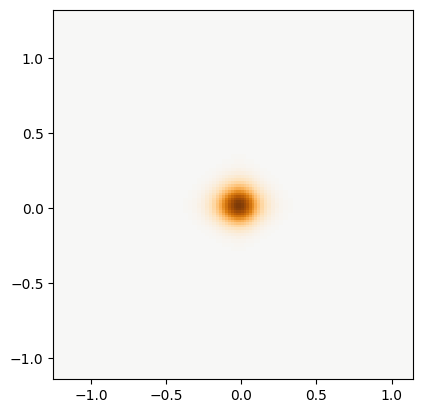

In [12]:
plt.pcolormesh(
    source_edges[1][:, 0],
    source_edges[1][:, 1],
    source,
    # shading = 'flat' requires the pixel *edges*, other shadings require the pixel *centers*, see matplotlib's documentation for details
    shading='flat',
    cmap=new_cmap,
    vmin=0
)
plt.gca().set_aspect(1)

It can be a bit difficult to tell in the above image, but the pixel are all different sizes.  We can see this more clearly if we plot the corners of each of the pixels as dots.

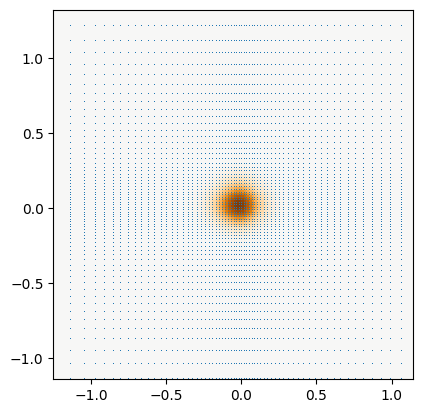

In [13]:
plt.pcolormesh(
    source_edges[1][:, 0],
    source_edges[1][:, 1],
    source,
    # shading = 'flat' requires the pixel *edges*, other shadings require the pixel *centers*, see matplotlib's documentation for details
    shading='flat',
    cmap=new_cmap,
    vmin=0
)

a, b = np.meshgrid(*source_edges[1].T)
plt.plot(a.flatten(), b.flatten(), ',')
plt.gca().set_aspect(1);

## Compare to a regular grid

To compar this lens model to a regular grid we first need to take the source galaxy in the observed coordinates and interpolate it onto a regular grid.

In [14]:
centers_min = source_centers[1][0]
centers_max = source_centers[1][-1]

xi = np.meshgrid(
    jnp.linspace(centers_min[0], centers_max[0], pixel_grid_shape),
    jnp.linspace(centers_min[1], centers_max[1], pixel_grid_shape),
)
source_real_space = interpn(
    np.array(source_centers[1].T),
    np.array(source),
    np.moveaxis(np.array(xi), 0, 2),
    bounds_error=False,
    fill_value=0.0,
    method='linear'
)

kwargs_source_real = [{'pixels': source_real_space}]

We can now make a regular pixel grid model by passing in a `PixelatedLight` with `adaptive_grid=True` and not setting any of the `rtu_*` keywords.

Note: As `LightModelRTU` and `PixelatedLightRTU` are subclasses of the originals they will act the same as before when none of the new keywords are set.

In [15]:
source_input = LightModelRTU([
    PixelatedLightRTU(
        interpolation_type='fast_bilinear',
        derivative_type='autodiff',
        adaptive_grid=True,
        allow_extrapolation=False
    )
], kwargs_pixelated={'num_pixels': pixel_grid_shape})


lens_image = LensImageRTUGrid(
    pixel_grid, psf_holder, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input,
    kwargs_numerics=kwargs_numerics,
    source_arc_mask=mask
)

In [16]:
model = lens_image.model(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_real, PSF_class=psf_rtu)

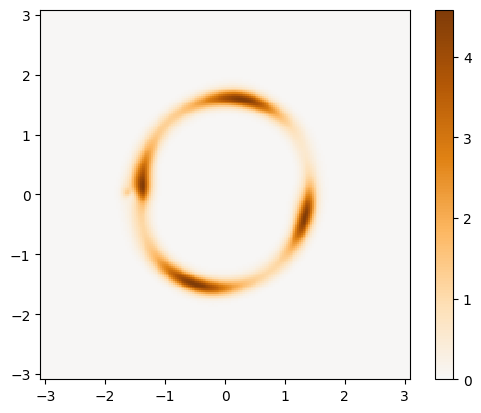

In [17]:
plt.imshow(model, extent=pixel_grid.extent, cmap=new_cmap, vmin=0)
plt.colorbar();

This looks identical to the version using the RTU-grid.

Note: If you take the differences of the two models you will notice there is a slight shift between them, this is because the coordinates calculated with `adaptive_grid=True` are slightly different than the ones calculated with the RTU-grid.

## Speed comparisons

In this section we will look at the computational overhead associated with the RTU-grid transformation compared to a regular grid.

Note: The timings below are from running on an A100 GPU, CPU scaling is very different.

### Model evaluation

In [18]:
%timeit jax.block_until_ready(lens_image.model(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_real, PSF_class=psf_rtu))

48 ms ± 4.31 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [19]:
%timeit jax.block_until_ready(lens_image_rtu.model(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_uniform, PSF_class=psf_rtu))

77.8 ms ± 2.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


We see that there is some computational overhead associated with a model evaluation.  This overhead is (fractionally) similar regardless of the supersampling level.  Some part of this overhead comes from fitting the transformation function (one additional ray cast for each observed pixel in the arc mask and a polynomial fit), with the rest coming from the transform function evaluation (a cubic spline) that every supersampled ray is passed through.

While there is a performance cost to this method (that at least on a GPU is quite mild), the resulting RTU-grid inference can produce as good (or better) results with a source pixel grid that is up to 2x smaller on each side (e.g. 4x fewer free parameters) than the regular grid.  Depending on the inference method being used this dimensionality reduction could more than make up for the extra model evaluation time.

Note: the `model` method already has `jax.jit` applied to it in the class definition and the methods are already compiled because they were both already run earlier in the notebook

### Model and gradient evaluation

As this code is all based in `jax` we can make use of gradient informed inference methods (e.g. SVI, NUTS, etc...).  In these methods a loss function is defined that produces a scalar value that is being minimized and the gradient of the loss function with respect to each input variable is used to define "down hill" in this loss space.  To test the computational overhead of the gradient calculation we will create some "psudo-loss functions" and use `jax.value_and_grad` to find the value and gradient with respect to all the input parameters.

Note: we need to make sure to `jax.jit` the `jax.value_and_grad` function and run it once to make sure the code is compiled *before* doing out timing tests

In [20]:
# an extremely simplified loss function to be used for testing relative timings
def loss_regular(kwargs):
    m = lens_image.model(**kwargs, PSF_class=psf_rtu)
    m_var = noise.C_D_model(model, 0.01)
    return (0.5 * m**2 / m_var + jnp.log(m_var)).sum()


v_and_g_regular = jax.jit(jax.value_and_grad(loss_regular))


def loss_rtu(kwargs):
    m = lens_image_rtu.model(**kwargs, PSF_class=psf_rtu)
    m_var = noise.C_D_model(model, 0.01)
    return (0.5 * m**2 / m_var + jnp.log(m_var)).sum()


v_and_g_rtu = jax.jit(jax.value_and_grad(loss_rtu))

In [21]:
v_reg, g_reg = v_and_g_regular({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real})

In [22]:
v_rtu, g_rtu = v_and_g_rtu({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_uniform})

This first run is just to make sure the `jit`ed functions are both compiled.  We can see that the RTU-grid does take a few seconds longer to compile than the regular grid's loss function.

In [23]:
%timeit jax.block_until_ready(v_and_g_regular({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real}))

573 ms ± 57.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [24]:
%timeit jax.block_until_ready(v_and_g_rtu({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_uniform}))

1.22 s ± 17.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Again we see a similar (fractional) overhead in timings that we saw with just the model evaluation.  This shows that there is not much (if any) additional overhead in calculating the gradient values through the RTU-grid transformation.

## Memory analysis

The last thing we will look at in this example in the memory requirements when evaluating the model and its gradient.  The `LensImageRTUGrid` subclass adjusts how the lens model deals with supersampling to ensure that the memory requirements stay *fixed* regardless of the supersampling value.

### Model evaluation only

In [25]:
lowered_lens_image_model = lens_image.model.lower(lens_image, kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_real, PSF_class=psf_rtu)
compiled_lens_image_model = lowered_lens_image_model.compile()
memory_analysis_lens_image_model = compiled_lens_image_model.memory_analysis()
memory_in_MB_lens_image_model = (memory_analysis_lens_image_model.output_size_in_bytes + memory_analysis_lens_image_model.temp_size_in_bytes) / 1024**2
print(f'Regular: {memory_in_MB_lens_image_model} MB')

Regular: 3.0532455444335938 MB


In [26]:
lowered_lens_image_rtu_model = lens_image_rtu.model.lower(lens_image_rtu, kwargs_lens=kwargs_lens, kwargs_source=kwargs_source_uniform, PSF_class=psf_rtu)
compiled_lens_image_rtu_model = lowered_lens_image_rtu_model.compile()
memory_analysis_lens_image_rtu_model = compiled_lens_image_rtu_model.memory_analysis()
memory_in_MB_lens_image_rtu_model = (memory_analysis_lens_image_rtu_model.output_size_in_bytes + memory_analysis_lens_image_rtu_model.temp_size_in_bytes) / 1024**2
print(f'RTU-grid: {memory_in_MB_lens_image_rtu_model} MB')

RTU-grid: 10.073333740234375 MB


We can see that the RTU-grid needs a bit more memory than the regular grid, but still on the order of a few MB.

### Model and gradient


In [27]:
lowered_loss_regular = v_and_g_regular.lower({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real})
compiled_loss_regular = lowered_loss_regular.compile()
memory_analysis_loss_regular = compiled_loss_regular.memory_analysis()
memory_in_MB_loss_regular = (memory_analysis_loss_regular.output_size_in_bytes + memory_analysis_loss_regular.temp_size_in_bytes) / 1024**2
print(f'Regular: {memory_in_MB_loss_regular} MB')

Regular: 70.94454956054688 MB


In [28]:
lowered_loss_rtu = v_and_g_rtu.lower({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_uniform})
compiled_loss_rtu = lowered_loss_rtu.compile()
memory_analysis_loss_rtu = compiled_loss_rtu.memory_analysis()
memory_in_MB_loss_rtu = (memory_analysis_loss_rtu.output_size_in_bytes + memory_analysis_loss_rtu.temp_size_in_bytes) / 1024**2
print(f'RTU-grid: {memory_in_MB_loss_rtu} MB')

RTU-grid: 68.30036163330078 MB


Interestingly the memory requirement for the loss function with its gradient is *lower* for the RTU-grid than the regular grid, but in either case the cost is still below 75 MB.

### No scaling with supersampling

Now we can confirm the claim that the new subclass is independent of supersampling.  We will set the supersampling value to `10` to really show this off.

In [30]:
lens_image_10ss = LensImageRTUGrid(
    pixel_grid, psf_holder, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input,
    kwargs_numerics={'supersampling_factor': 10},
    source_arc_mask=mask
)

lens_image_rtu_10ss = LensImageRTUGrid(
    pixel_grid, psf_holder, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input_rtu,
    kwargs_numerics={'supersampling_factor': 10},
    source_arc_mask=mask,
)


def loss_regular_10ss(kwargs):
    m = lens_image_10ss.model(**kwargs, PSF_class=psf_rtu)
    m_var = noise.C_D_model(model, 0.01)
    return (0.5 * m**2 / m_var + jnp.log(m_var)).sum()


v_and_g_regular_10ss = jax.jit(jax.value_and_grad(loss_regular_10ss))
lowered_loss_regular_10ss = v_and_g_regular_10ss.lower({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real})
compiled_loss_regular_10ss = lowered_loss_regular_10ss.compile()
memory_analysis_loss_regular_10ss = compiled_loss_regular_10ss.memory_analysis()
memory_in_MB_loss_regular_10ss = (memory_analysis_loss_regular_10ss.output_size_in_bytes + memory_analysis_loss_regular_10ss.temp_size_in_bytes) / 1024**2
print(f'Regular 10x supersampling: {memory_in_MB_loss_regular_10ss} MB')


def loss_rtu_10ss(kwargs):
    m = lens_image_rtu_10ss.model(**kwargs, PSF_class=psf_rtu)
    m_var = noise.C_D_model(model, 0.01)
    return (0.5 * m**2 / m_var + jnp.log(m_var)).sum()


v_and_g_rtu_10ss = jax.jit(jax.value_and_grad(loss_rtu_10ss))
lowered_loss_rtu_10ss = v_and_g_rtu_10ss.lower({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_uniform})
compiled_loss_rtu_10ss = lowered_loss_rtu_10ss.compile()
memory_analysis_loss_rtu_10ss = compiled_loss_rtu_10ss.memory_analysis()
memory_in_MB_loss_rtu_10ss = (memory_analysis_loss_rtu_10ss.output_size_in_bytes + memory_analysis_loss_rtu_10ss.temp_size_in_bytes) / 1024**2
print(f'RTU-grid 10x supersampling: {memory_in_MB_loss_rtu_10ss} MB')

Regular 10x supersampling: 70.94522094726562 MB
RTU-grid 10x supersampling: 68.30103302001953 MB


As promised, the memory footprint is identical!

### The original LensImage class

For completeness we will look at the loos function scaling for the original `LensImage` class at both 4x and 10x supersampling.

In [31]:
psf_base = PSF(psf_type='PIXEL', kernel_point_source=psf_kernel)

lens_image_base = LensImage(
    pixel_grid, psf_base, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input,
    kwargs_numerics={'supersampling_factor': 4},
    source_arc_mask=mask
)

lens_image_base_10ss = LensImage(
    pixel_grid, psf_base, noise,
    lens_mass_model_class=lens_mass_input,
    source_model_class=source_input,
    kwargs_numerics={'supersampling_factor': 10},
    source_arc_mask=mask
)


def loss_base(kwargs):
    m = lens_image_base.model(**kwargs)
    m_var = noise.C_D_model(model, 0.01)
    return (0.5 * m**2 / m_var + jnp.log(m_var)).sum()


v_and_g_base = jax.jit(jax.value_and_grad(loss_base))
lowered_loss_base = v_and_g_base.lower({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real})
compiled_loss_base = lowered_loss_base.compile()
memory_analysis_loss_base = compiled_loss_base.memory_analysis()
memory_in_MB_loss_base = (memory_analysis_loss_base.output_size_in_bytes + memory_analysis_loss_base.temp_size_in_bytes) / 1024**2
print(f'Regular 4x supersampling: {memory_in_MB_loss_base} MB')


def loss_base_10ss(kwargs):
    m = lens_image_base_10ss.model(**kwargs)
    m_var = noise.C_D_model(model, 0.01)
    return (0.5 * m**2 / m_var + jnp.log(m_var)).sum()

v_and_g_base_10ss = jax.jit(jax.value_and_grad(loss_base_10ss))
lowered_loss_base_10ss = v_and_g_base_10ss.lower({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real})
compiled_loss_base_10ss = lowered_loss_base_10ss.compile()
memory_analysis_loss_base_10ss = compiled_loss_base_10ss.memory_analysis()
memory_in_MB_loss_base_10ss = (memory_analysis_loss_base_10ss.output_size_in_bytes + memory_analysis_loss_base_10ss.temp_size_in_bytes) / 1024**2
print(f'Regular 10x supersampling: {memory_in_MB_loss_base_10ss} MB')


Regular 4x supersampling: 638.7036590576172 MB


2026-07-06 14:12:53.816656: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window.1 = f64[1,1,200,200]{3,2,1,0} reduce-window(f64[1,1,2000,2000]{3,2,1,0} %broadcast.357, f64[] %constant.218), window={size=1x1x10x10 stride=1x1x10x10}, to_apply=%region_22.1174, metadata={op_name="jit(loss_base_10ss)/jit(main)/jvp(jit(model))/reduce_window_sum" source_file="/var/folders/0c/27cmfjj10js1rt_sp9cxxb3h0000gp/T/ipykernel_74637/1611851751.py" source_line=35}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-07-06 14:12:55.186490: E external/xla/xla/service/slow_operation_alarm.cc:

Regular 10x supersampling: 3792.5809173583984 MB


Here we can see a big difference, at 4x supersampling the original LensImage class would use nearly 600MB of memory (10x what is needed with the new subclass).  This amount scales with the supersampling size and at 10x it needs 3.5GB (nearly 60x what is needed with the new subclass).  The cost savings of the new method comes down to the new subclass never storing the full supersampled grid at once, instead tracking a running average of all the sub-pixels that will be combined together in the final output.

### One last speed test

Finally we can look at the speed of the original class at 4x supersampling to see what that extra memory usage gets us.

In [ ]:
%timeit jax.block_until_ready(compiled_loss_base({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real}))

We do see that the code is indeed a touch faster with the original class showing there is a clear tradeoff between speed efficiency and memory efficiency.

And for completeness we can run the speed tests for the 10x supersampled cases.

In [ ]:
%timeit jax.block_until_ready(compiled_loss_base_10ss({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real}))

In [ ]:
%timeit jax.block_until_ready(compiled_loss_regular_10ss({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_real}))

In [ ]:
%timeit jax.block_until_ready(compiled_loss_rtu_10ss({'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source_uniform}))

The values we are showing here are for a very simplified loss function with none of the optimizer or sampler overhead added in.  We have found that being more memory efficient has been a large help when dealing with high resolution imaging (e.g. JWST) where even mild supersampling values would push our code to the limits of our GPU's vRAM when multiple sampler chains are run in parallel.  Being able to run the model, even if it is slower, is better than not being able to run it at all.

To give more real-world numbers, a typical SVI run on Euclid data (100x100 pixel cutouts) with 4x supersampling, an SIE + Shear mass model, 30 gaussian light components for the lens light, a 64x64 RTU-grid source, and 5 chains running in parallel uses around 400MB of memory.  The same model running without the "low memory" modifications is closer to 6GB.  Given that modern GPUs such as the A100 can be split into smaller "Multi-Instance GPUs" (MIG) partitions, there is scope for many more instances of the code to be deployed to a single physical GPU when the memory footprint is small enough to fit onto these partitions.